## **Connect Colab**

In [1]:
#conect with drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["GITHUB_TOKEN"] = "xx"
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"] = "xx"

In [3]:
#!sed -i 's/\r$//' /content/drive/MyDrive/apai/fetch_src.sh  # Windows users
!bash /content/drive/MyDrive/apai/fetch_src.sh

 fetch_src.sh — Download /src from GitHub

Checking environment...
GITHUB_TOKEN set
Fetching file list from GitHub API...
Found 12 file(s) under /src/
src/cl_strategies/naive.py -> /content/src/cl_strategies/naive.py
src/cl_strategies/reharsal.py -> /content/src/cl_strategies/reharsal.py
src/config/config.py -> /content/src/config/config.py
src/data/dataset.py -> /content/src/data/dataset.py
src/data/preprocessing.py -> /content/src/data/preprocessing.py
src/data/study_dataset.py -> /content/src/data/study_dataset.py
src/fine_tune/trainer.py -> /content/src/fine_tune/trainer.py
src/fine_tune/visualizer.py -> /content/src/fine_tune/visualizer.py
src/imports.py -> /content/src/imports.py
src/models/baselines.py -> /content/src/models/baselines.py
src/models/pretrained.py -> /content/src/models/pretrained.py
src/utils/save.py -> /content/src/utils/save.py

 All files saved under /content/src/
Contents of /content/src/:
/content/src/cl_strategies/naive.py
/content/src/cl_strategies/reharsa

## **Download DATASET**

In [4]:
#!sed -i 's/\r$//' /content/drive/MyDrive/apai/setup_colab.sh    # Windows users
!bash /content/drive/MyDrive/apai/setup_colab.sh


UCF101 Project — Colab Setup Script

Checking environment...
KAGGLE_USERNAME set
KAGGLE_KEY set
config.py found

Installing kagglehub...
Done.

Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
Dataset path: /kaggle/input/ucf101-action-recognition

Detecting path and updating config.py...
Found in Kaggle input: /kaggle/input/ucf101-action-recognition/
DATASET_ROOT = '/kaggle/input/ucf101-action-recognition/'
OUTPUT_ROOT  = '/kaggle/working/ucf101-processed/'

Setup complete!
config.py updated on Drive.
Restarting kernel in 5 seconds...
Dataset cache stays on disk.
Run Cell 3 after restart to verify.
Restarting in 5...
Restarting in 4...
Restarting in 3...
Restarting in 2...
Restarting in 1...


In [5]:
# imports
%run /content/src/imports.py

Using device: cuda


## **Preprocess data**

In [6]:
# BASE
cfg.OUTPUT_ROOT = "./UCF101/processed_data_base"
preprocess_dataset(splits=["test"], target_classes=cfg.SELECTED_CLASSES)


--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_data_base
Classes: 10 | Limit: Full

Processing split: test



Done! Dataset ready at: ./UCF101/processed_data_base


In [7]:

# TASK 1
cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task1"
preprocess_dataset(splits=["train", "val", "test"], target_classes=cfg.TASK_1)

# TASK 2
cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task2"
preprocess_dataset(splits=["train", "val", "test"], target_classes=cfg.TASK_2)

# TASK 3
#cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task3"
#preprocess_dataset(splits=["train", "val", "test"])

# TASK 4
#cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task4"
#preprocess_dataset(splits=["train", "val", "test"])


--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_data_task1
Classes: 3 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: ./UCF101/processed_data_task1

--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_data_task2
Classes: 3 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: ./UCF101/processed_data_task2


In [8]:
cfg.SELECTED_CLASSES

['PlayingTabla',
 'PommelHorse',
 'JumpingJack',
 'PushUps',
 'PoleVault',
 'HorseRace',
 'HighJump',
 'Drumming',
 'HorseRiding',
 'Diving']

In [9]:
print(cfg.SELECTED_CLASSES + cfg.TASK_1)

['PlayingTabla', 'PommelHorse', 'JumpingJack', 'PushUps', 'PoleVault', 'HorseRace', 'HighJump', 'Drumming', 'HorseRiding', 'Diving', 'ApplyEyeMakeup', 'ApplyLipstick', 'Archery']


In [10]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1

class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

print(f"\nclass_to_idx:\n{class_to_idx}")


class_to_idx:
{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12}


## **Create Loaders**

In [ ]:
base_test        = UCF101Clips(os.path.join(cfg.BASE_ROOT, "test"), class_to_idx=class_to_idx)
base_test_loader = DataLoader(base_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

task1_train = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task1_val   = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "val"),   class_to_idx=class_to_idx)
task1_test  = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx)

task1_train_loader = DataLoader(task1_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task1_val_loader   = DataLoader(task1_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_test_loader  = DataLoader(task1_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

combined_test        = ConcatDataset([base_test, task1_test])
combined_test_loader = DataLoader(combined_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

## **Upload Model**

In [12]:
model_base = ResNet50LSTM(num_classes = len(cfg.SELECTED_CLASSES)).to(device)
state      = torch.load(cfg.RESNET50_PATH, map_location=device)
model_base.load_state_dict(state)
model_base = unfreeze_all(model_base)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 125MB/s] 


In [13]:
# new_num_classes=len(ALL_CLASSES_LIST)
model_task1 = expand_classifier(model_base, new_num_classes=len(ALL_CLASSES_LIST))
model_task1 = unfreeze_all(model_task1).to(device)

In [14]:
results_baseline = evaluate_all_tasks(
    model            = model_task1,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader],
    combined_loaders = [combined_test_loader],
)

  base             -> Acc=0.9766  Loss=0.1630
  task1_only       -> Acc=0.0000  Loss=3.3487
  combined_t1      -> Acc=0.7455  Loss=0.9167


In [15]:
print(f"model_task1 FC: in={model_task1.fc.in_features}  out={model_task1.fc.out_features}")

model_task1 FC: in=256  out=13


## **Task One**

In [16]:
train_task1 = train_model(
    model        = model_task1,
    train_loader = task1_train_loader,
    val_loader   = task1_val_loader,
)

Epoch [1/5] | Train Acc: 0.5316 Loss: 1.5573 | Val Acc: 0.9200 Loss: 0.5089


Epoch [2/5] | Train Acc: 0.9568 Loss: 0.3472 | Val Acc: 1.0000 Loss: 0.1303


Epoch [3/5] | Train Acc: 0.9701 Loss: 0.1513 | Val Acc: 1.0000 Loss: 0.0652


Epoch [4/5] | Train Acc: 1.0000 Loss: 0.0560 | Val Acc: 1.0000 Loss: 0.0387


Epoch [5/5] | Train Acc: 0.9967 Loss: 0.0436 | Val Acc: 1.0000 Loss: 0.0259


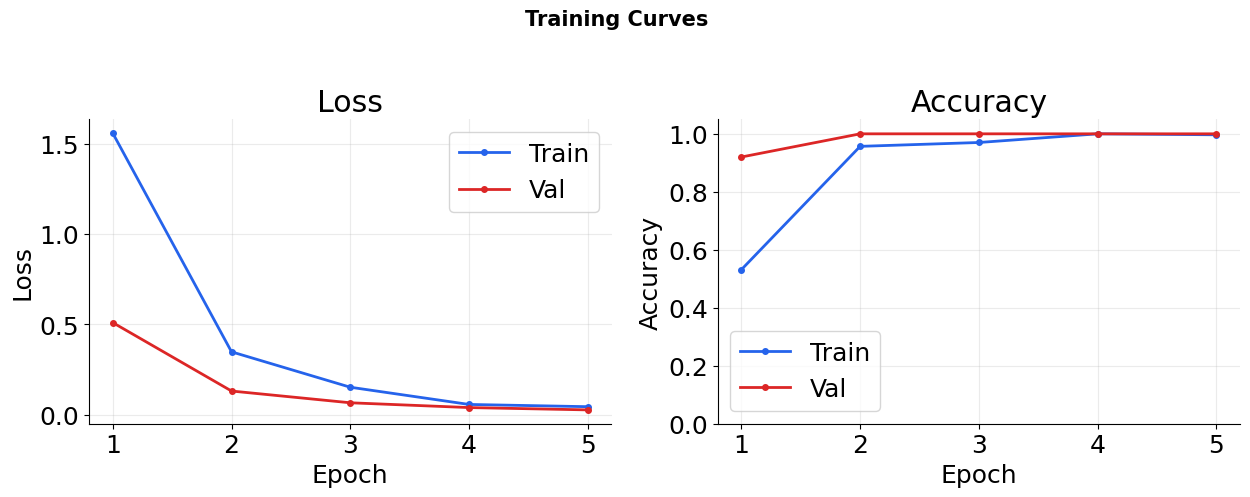

In [17]:
plot_training_results(train_task1)

In [18]:
results_after_t1 = evaluate_all_tasks(
    model   = model_task1,
    device  = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader],
    combined_loaders = [combined_test_loader],
)


  base             -> Acc=0.1520  Loss=3.2555
  task1_only       -> Acc=0.9811  Loss=0.0431
  combined_t1      -> Acc=0.3482  Loss=2.4954


Running Inference on Test Set...


Test Accuracy: 0.3482


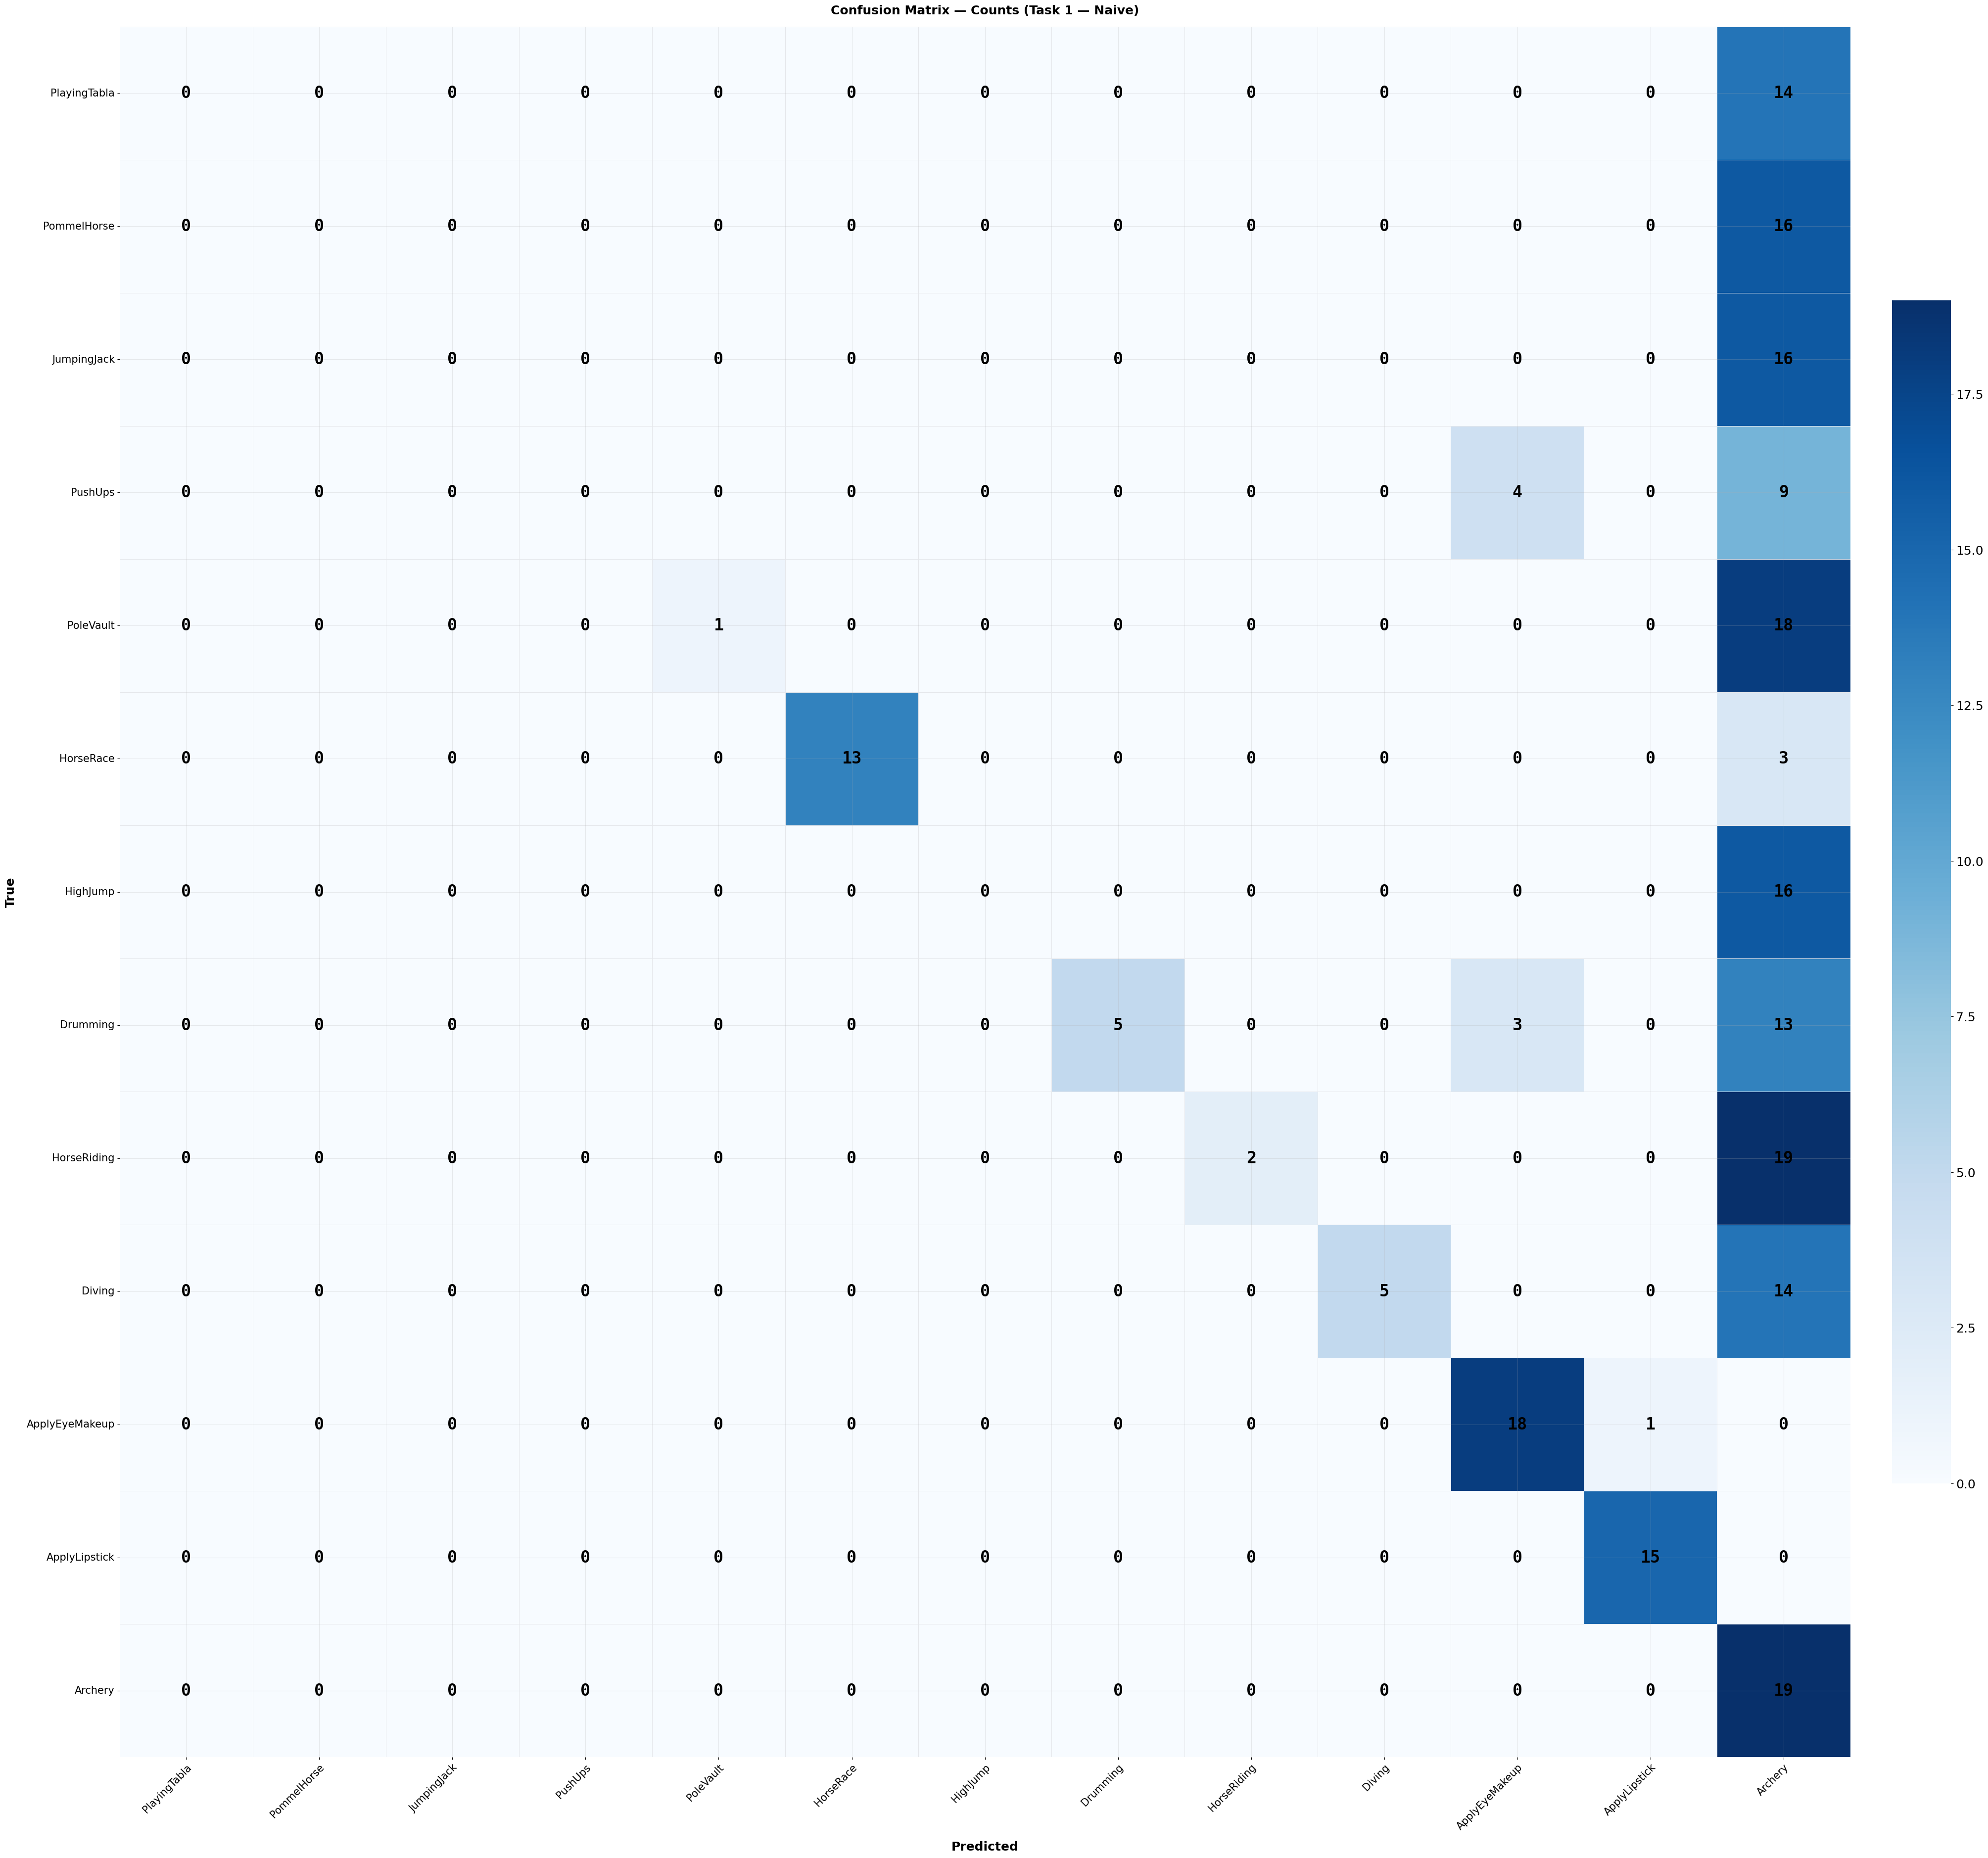

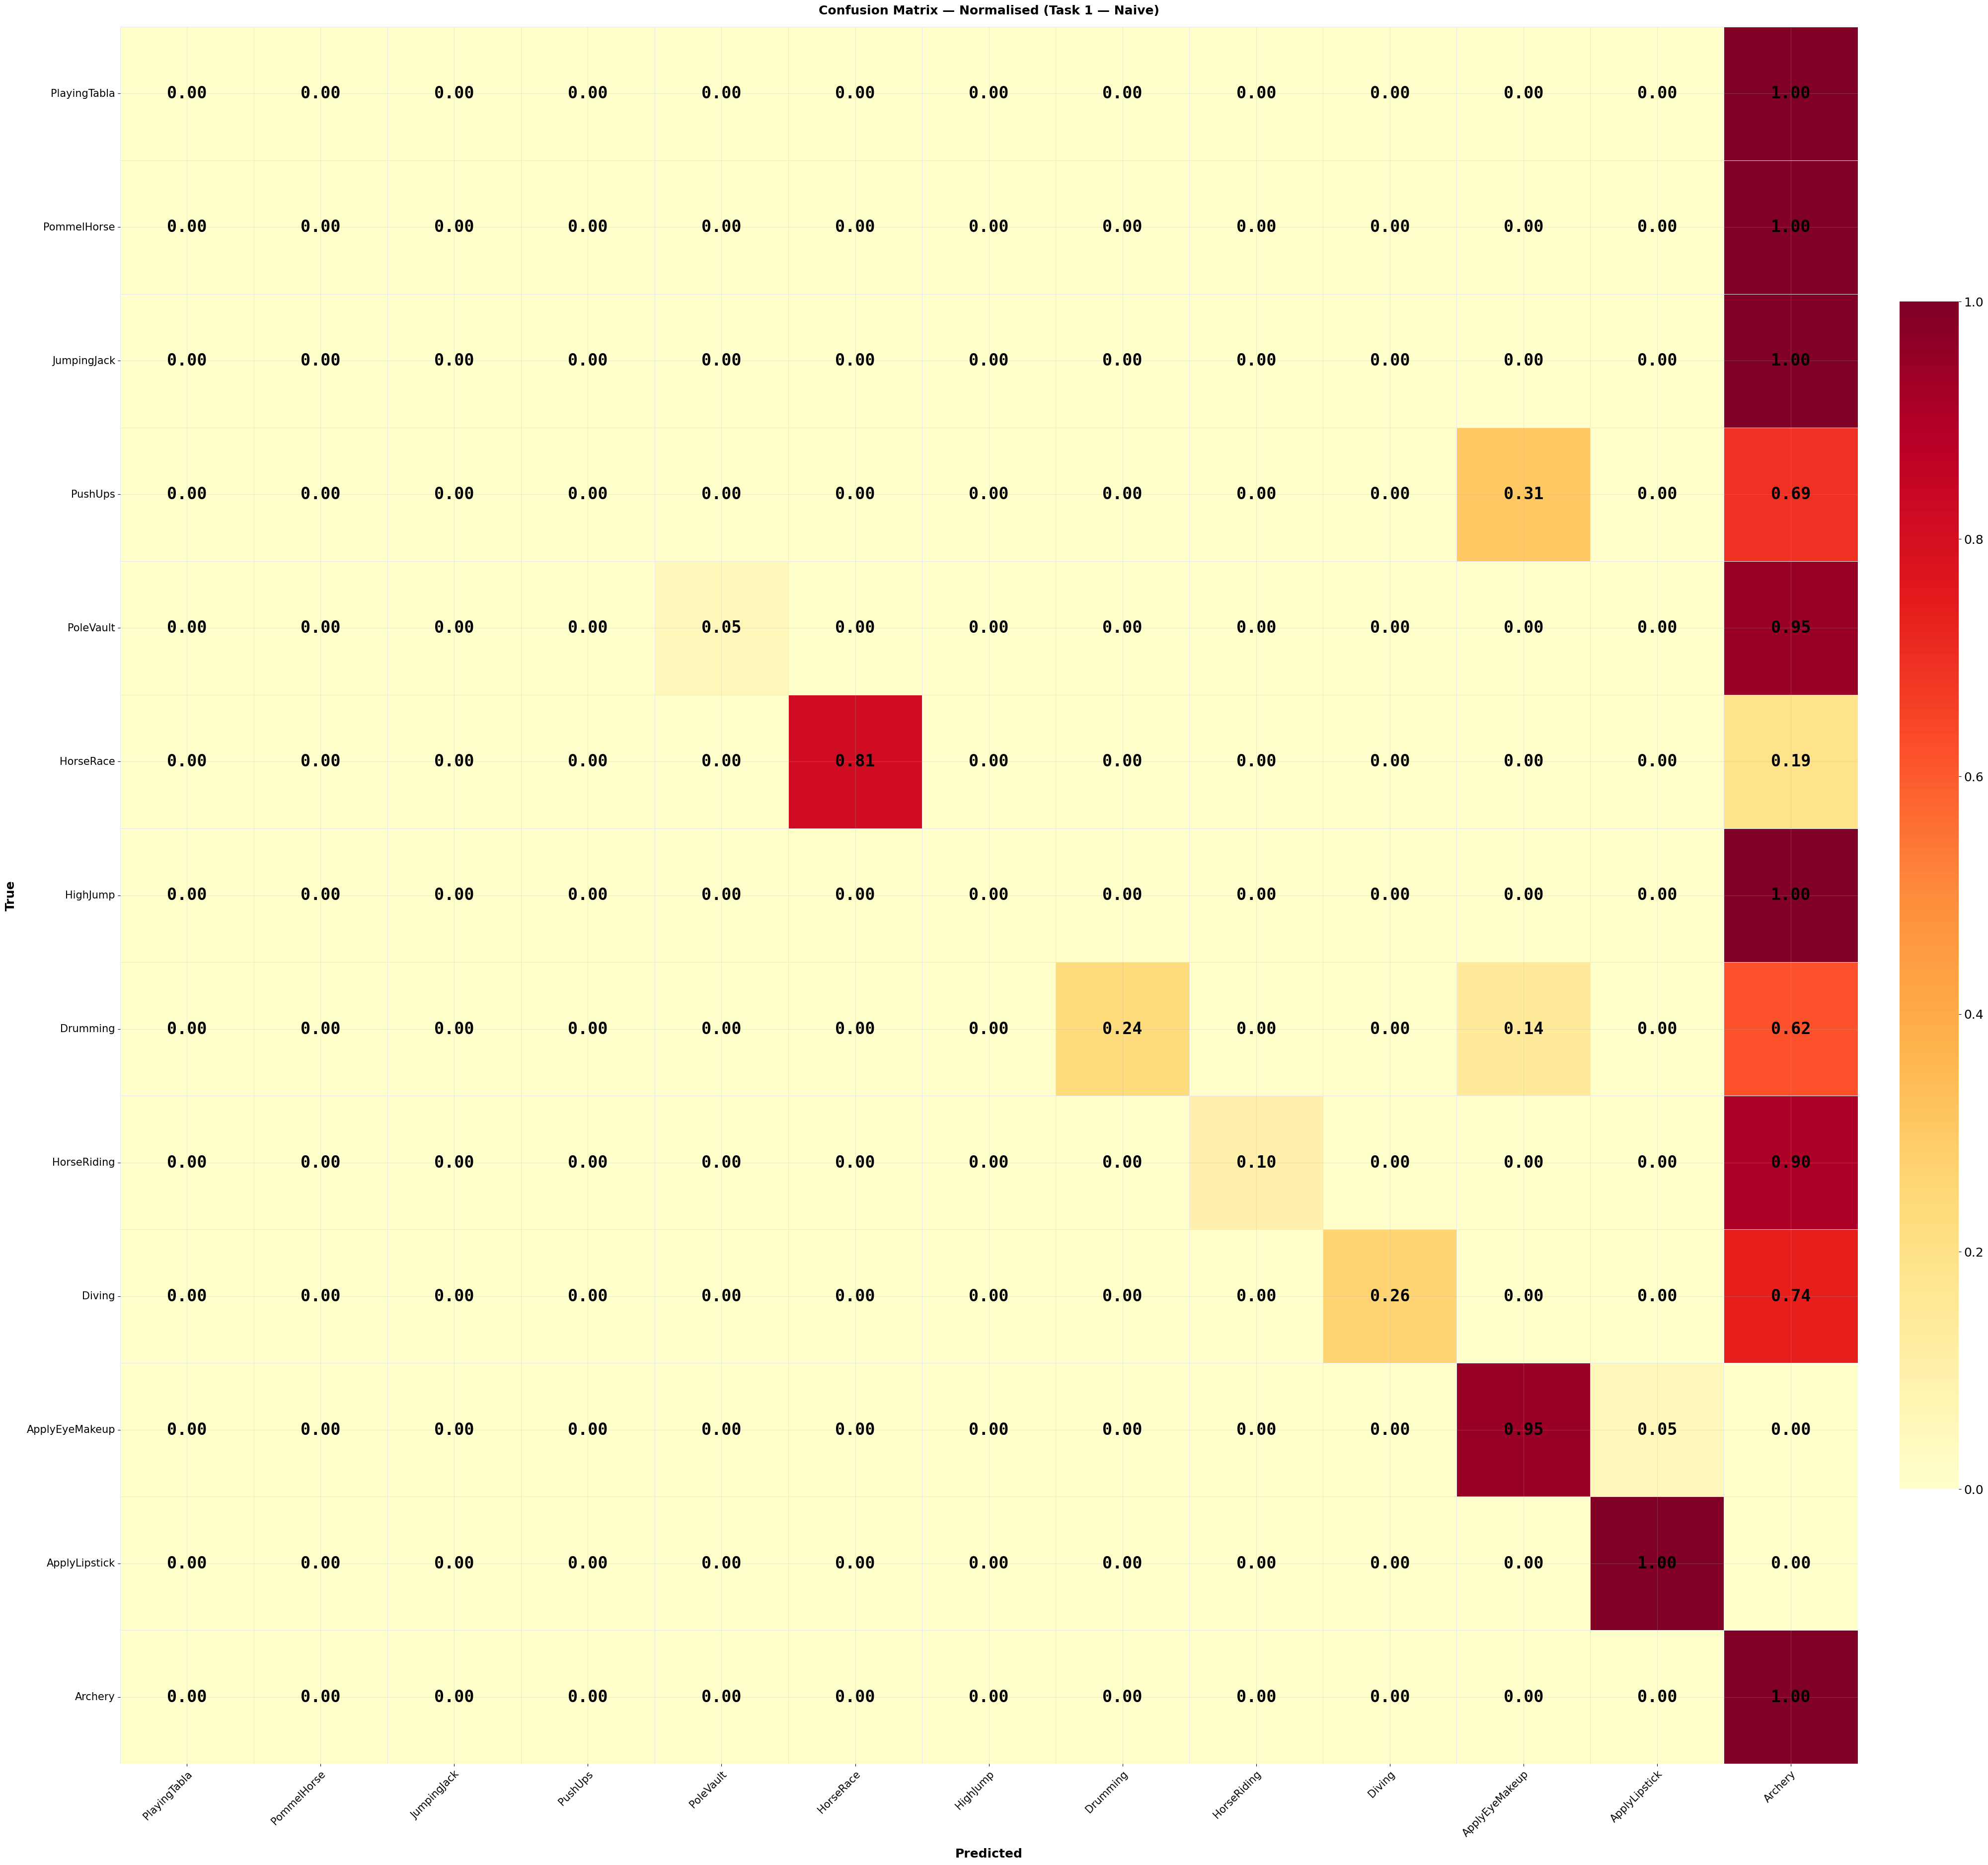

In [19]:
_, all_preds, all_labels = test_model(model_task1, combined_test_loader, device)

plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    name         = "Task 1 — Naive",
)

In [20]:
print_detailed_metrics(
    all_labels   = all_labels,
    all_preds    = all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    split_old    = (0, len(cfg.SELECTED_CLASSES)),               # base: 0–9
    split_new    = (len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST)),  # task1: 10–14
)


METRICS FOR 13 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.3482
  Precision : 0.5627
  Recall    : 0.3482
  F1-Score  : 0.3127

PER-CLASS REPORT 
                precision    recall  f1-score   support

  PlayingTabla       0.00      0.00      0.00        14
   PommelHorse       0.00      0.00      0.00        16
   JumpingJack       0.00      0.00      0.00        16
       PushUps       0.00      0.00      0.00        13
     PoleVault       1.00      0.05      0.10        19
     HorseRace       1.00      0.81      0.90        16
      HighJump       0.00      0.00      0.00        16
      Drumming       1.00      0.24      0.38        21
   HorseRiding       1.00      0.10      0.17        21
        Diving       1.00      0.26      0.42        19
ApplyEyeMakeup       0.72      0.95      0.82        19
 ApplyLipstick       0.94      1.00      0.97        15
       Archery       0.12      1.00      0.22        19

      accuracy                           0.35       224
    

## **Task 2**

In [21]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2

class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

print(f"\nclass_to_idx:\n{class_to_idx}")


class_to_idx:
{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BoxingPunchingBag': 13, 'BoxingSpeedBag': 14, 'BrushingTeeth': 15}


In [22]:
task2_train = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "train"), class_to_idx=class_to_idx)
task2_val   = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "val"),   class_to_idx=class_to_idx)
task2_test  = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "test"),  class_to_idx=class_to_idx)

task2_train_loader = DataLoader(task2_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task2_val_loader   = DataLoader(task2_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task2_test_loader  = DataLoader(task2_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

combined_test        = ConcatDataset([base_test, task1_test, task2_test])
combined_test_loader2 = DataLoader(combined_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

In [23]:
model_task2 = expand_classifier(model_base, new_num_classes=len(ALL_CLASSES_LIST))
model_task2 = unfreeze_all(model_task2).to(device)

In [24]:
results_baseline = evaluate_all_tasks(
    model            = model_task2,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader, task2_test_loader],
    combined_loaders = [combined_test_loader, combined_test_loader2],
)

  base             -> Acc=0.1520  Loss=3.3193
  task1_only       -> Acc=0.9811  Loss=0.0599
  task2_only       -> Acc=0.0000  Loss=4.4302
  combined_t1      -> Acc=0.3482  Loss=2.5481
  combined_t2      -> Acc=0.2796  Loss=2.9191


In [25]:
print(f"model_task1 FC: in={model_task1.fc.in_features}  out={model_task1.fc.out_features}")

model_task1 FC: in=256  out=16


In [26]:
train_task2 = train_model(
    model        = model_task2,
    train_loader = task2_train_loader,
    val_loader   = task2_val_loader,
)

Epoch [1/5] | Train Acc: 0.4437 Loss: 1.8973 | Val Acc: 0.9623 Loss: 0.5764


Epoch [2/5] | Train Acc: 0.9187 Loss: 0.4276 | Val Acc: 1.0000 Loss: 0.1346


Epoch [3/5] | Train Acc: 0.9750 Loss: 0.1568 | Val Acc: 1.0000 Loss: 0.0594


Epoch [4/5] | Train Acc: 0.9938 Loss: 0.0772 | Val Acc: 1.0000 Loss: 0.0345


Epoch [5/5] | Train Acc: 0.9938 Loss: 0.0534 | Val Acc: 1.0000 Loss: 0.0251


In [27]:
results_after_t2 = evaluate_all_tasks(
    model   = model_task2,
    device  = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader, task2_test_loader],
    combined_loaders = [combined_test_loader, combined_test_loader2],
)


  base             -> Acc=0.0409  Loss=3.8876
  task1_only       -> Acc=0.0000  Loss=4.7929
  task2_only       -> Acc=0.9818  Loss=0.0541
  combined_t1      -> Acc=0.0312  Loss=4.1018
  combined_t2      -> Acc=0.2186  Loss=3.3039


Running Inference on Test Set...


Test Accuracy: 0.2186


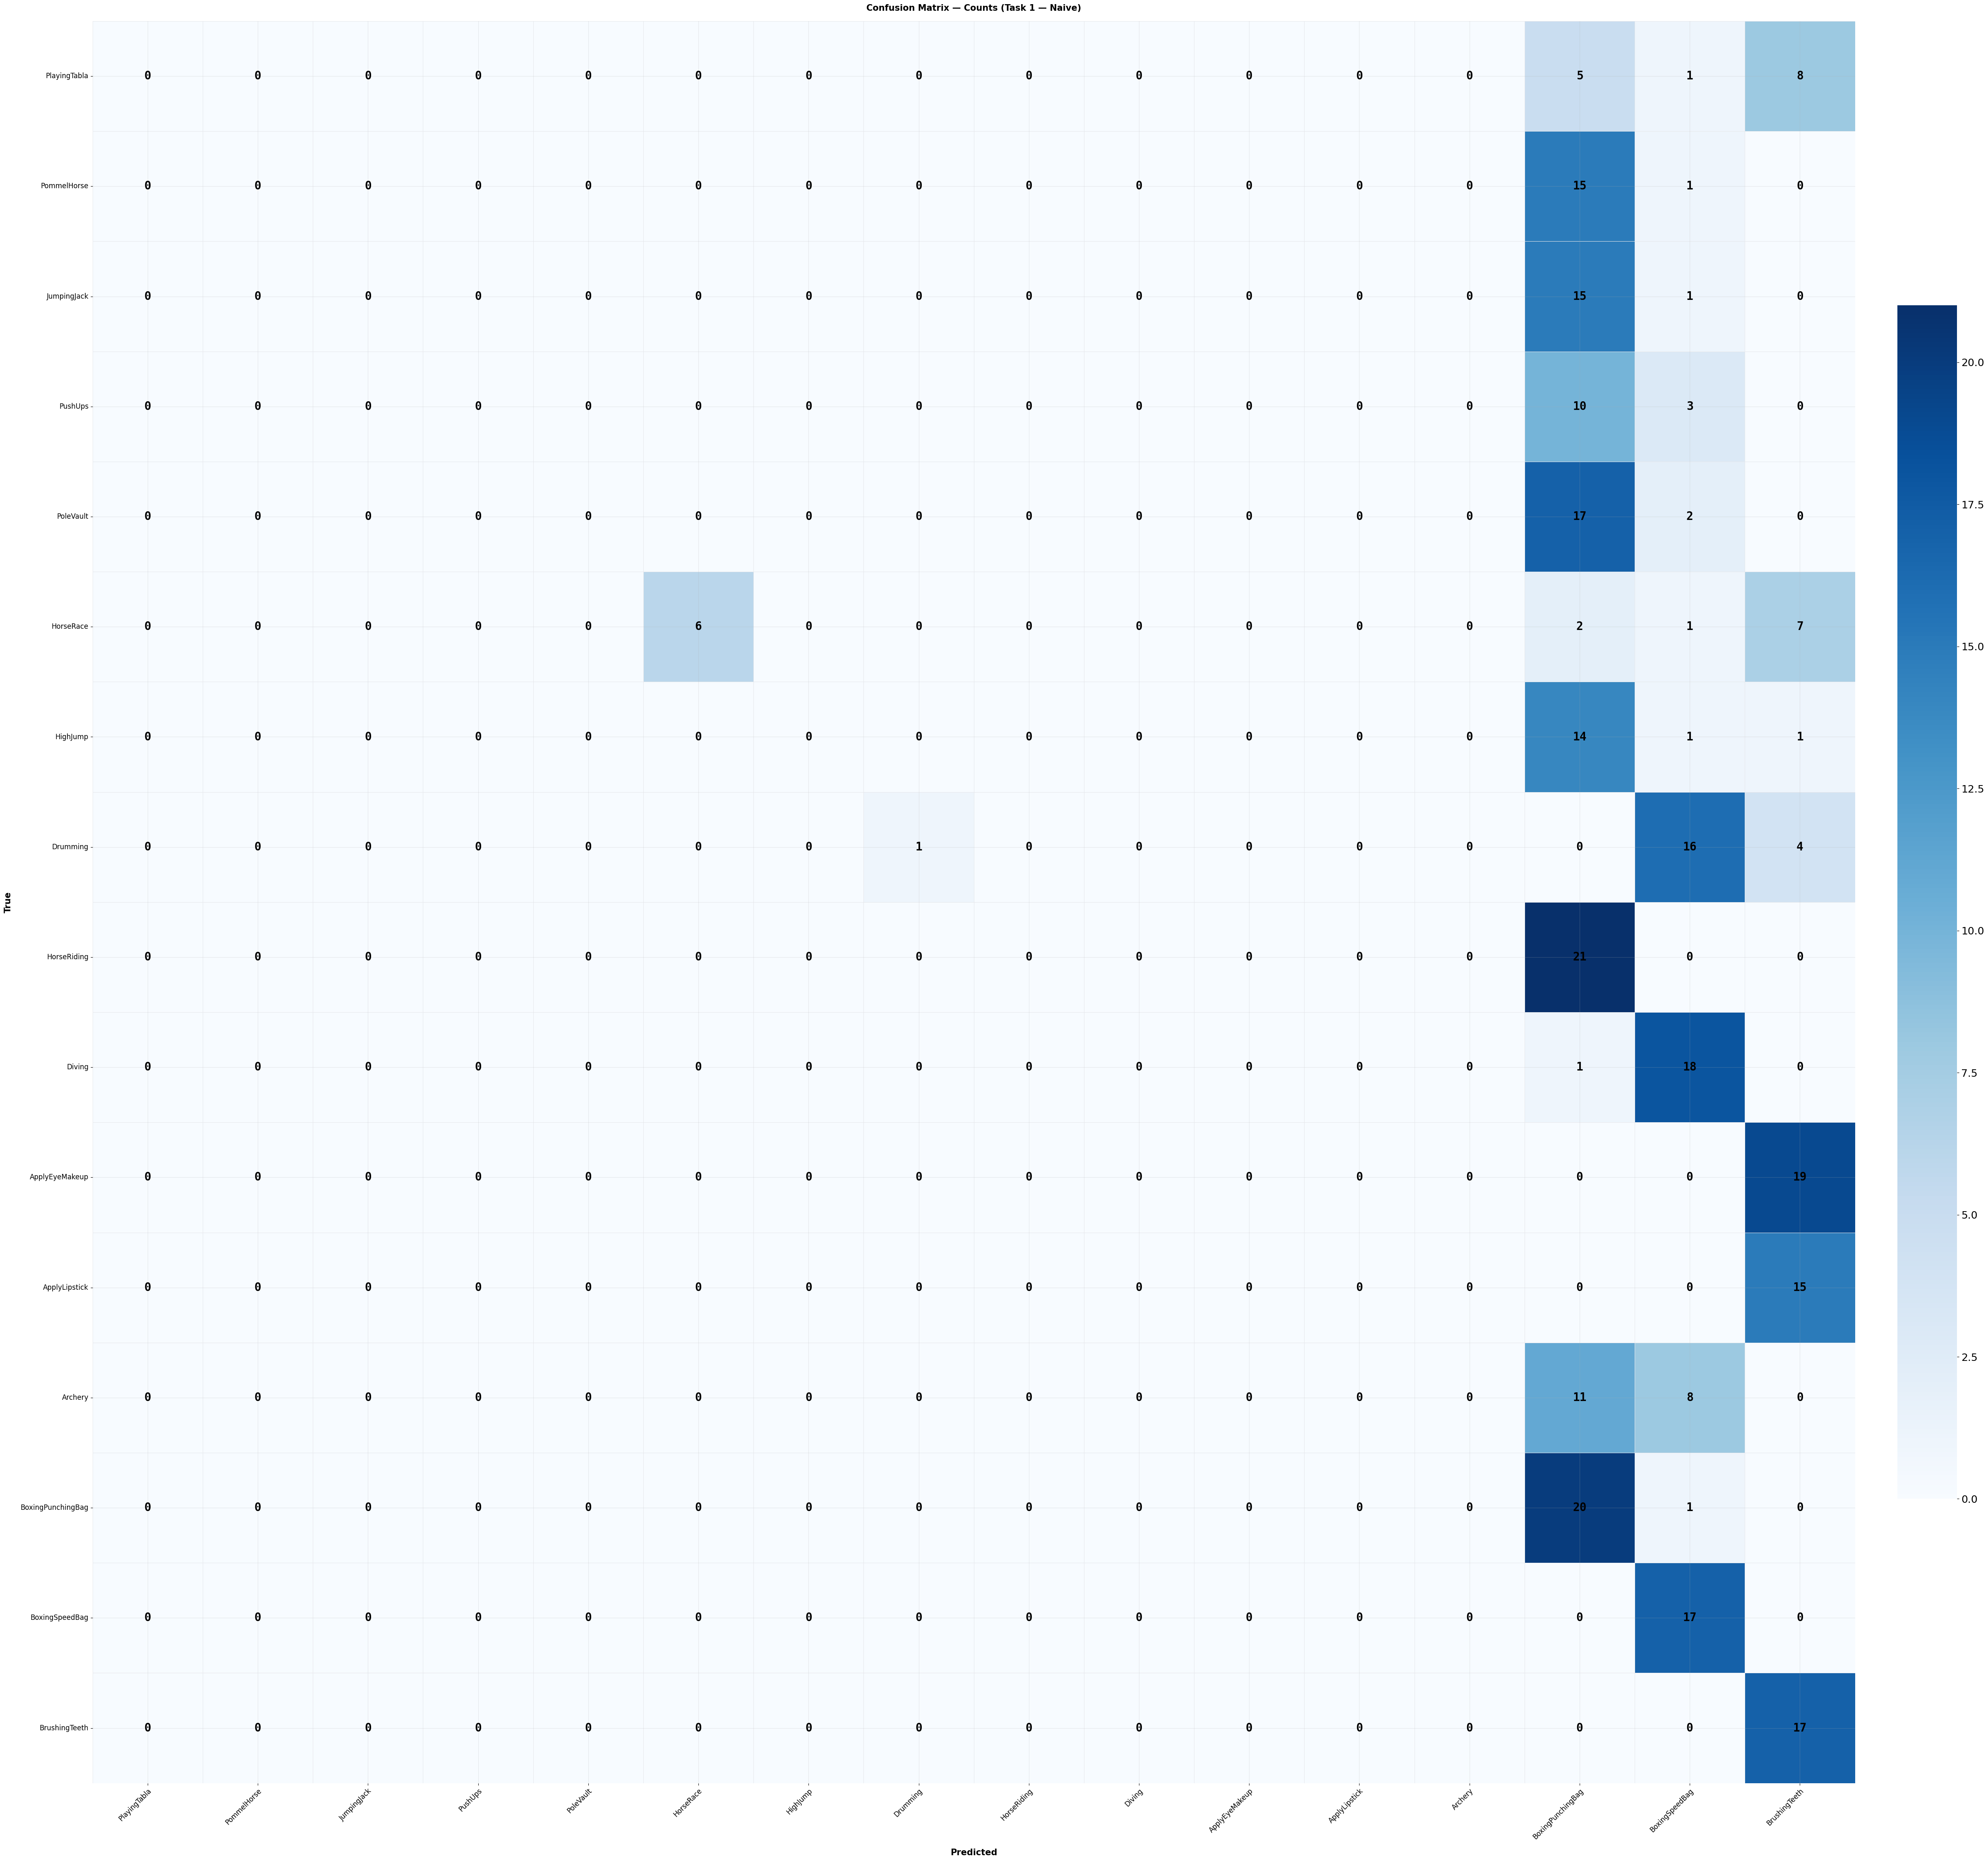

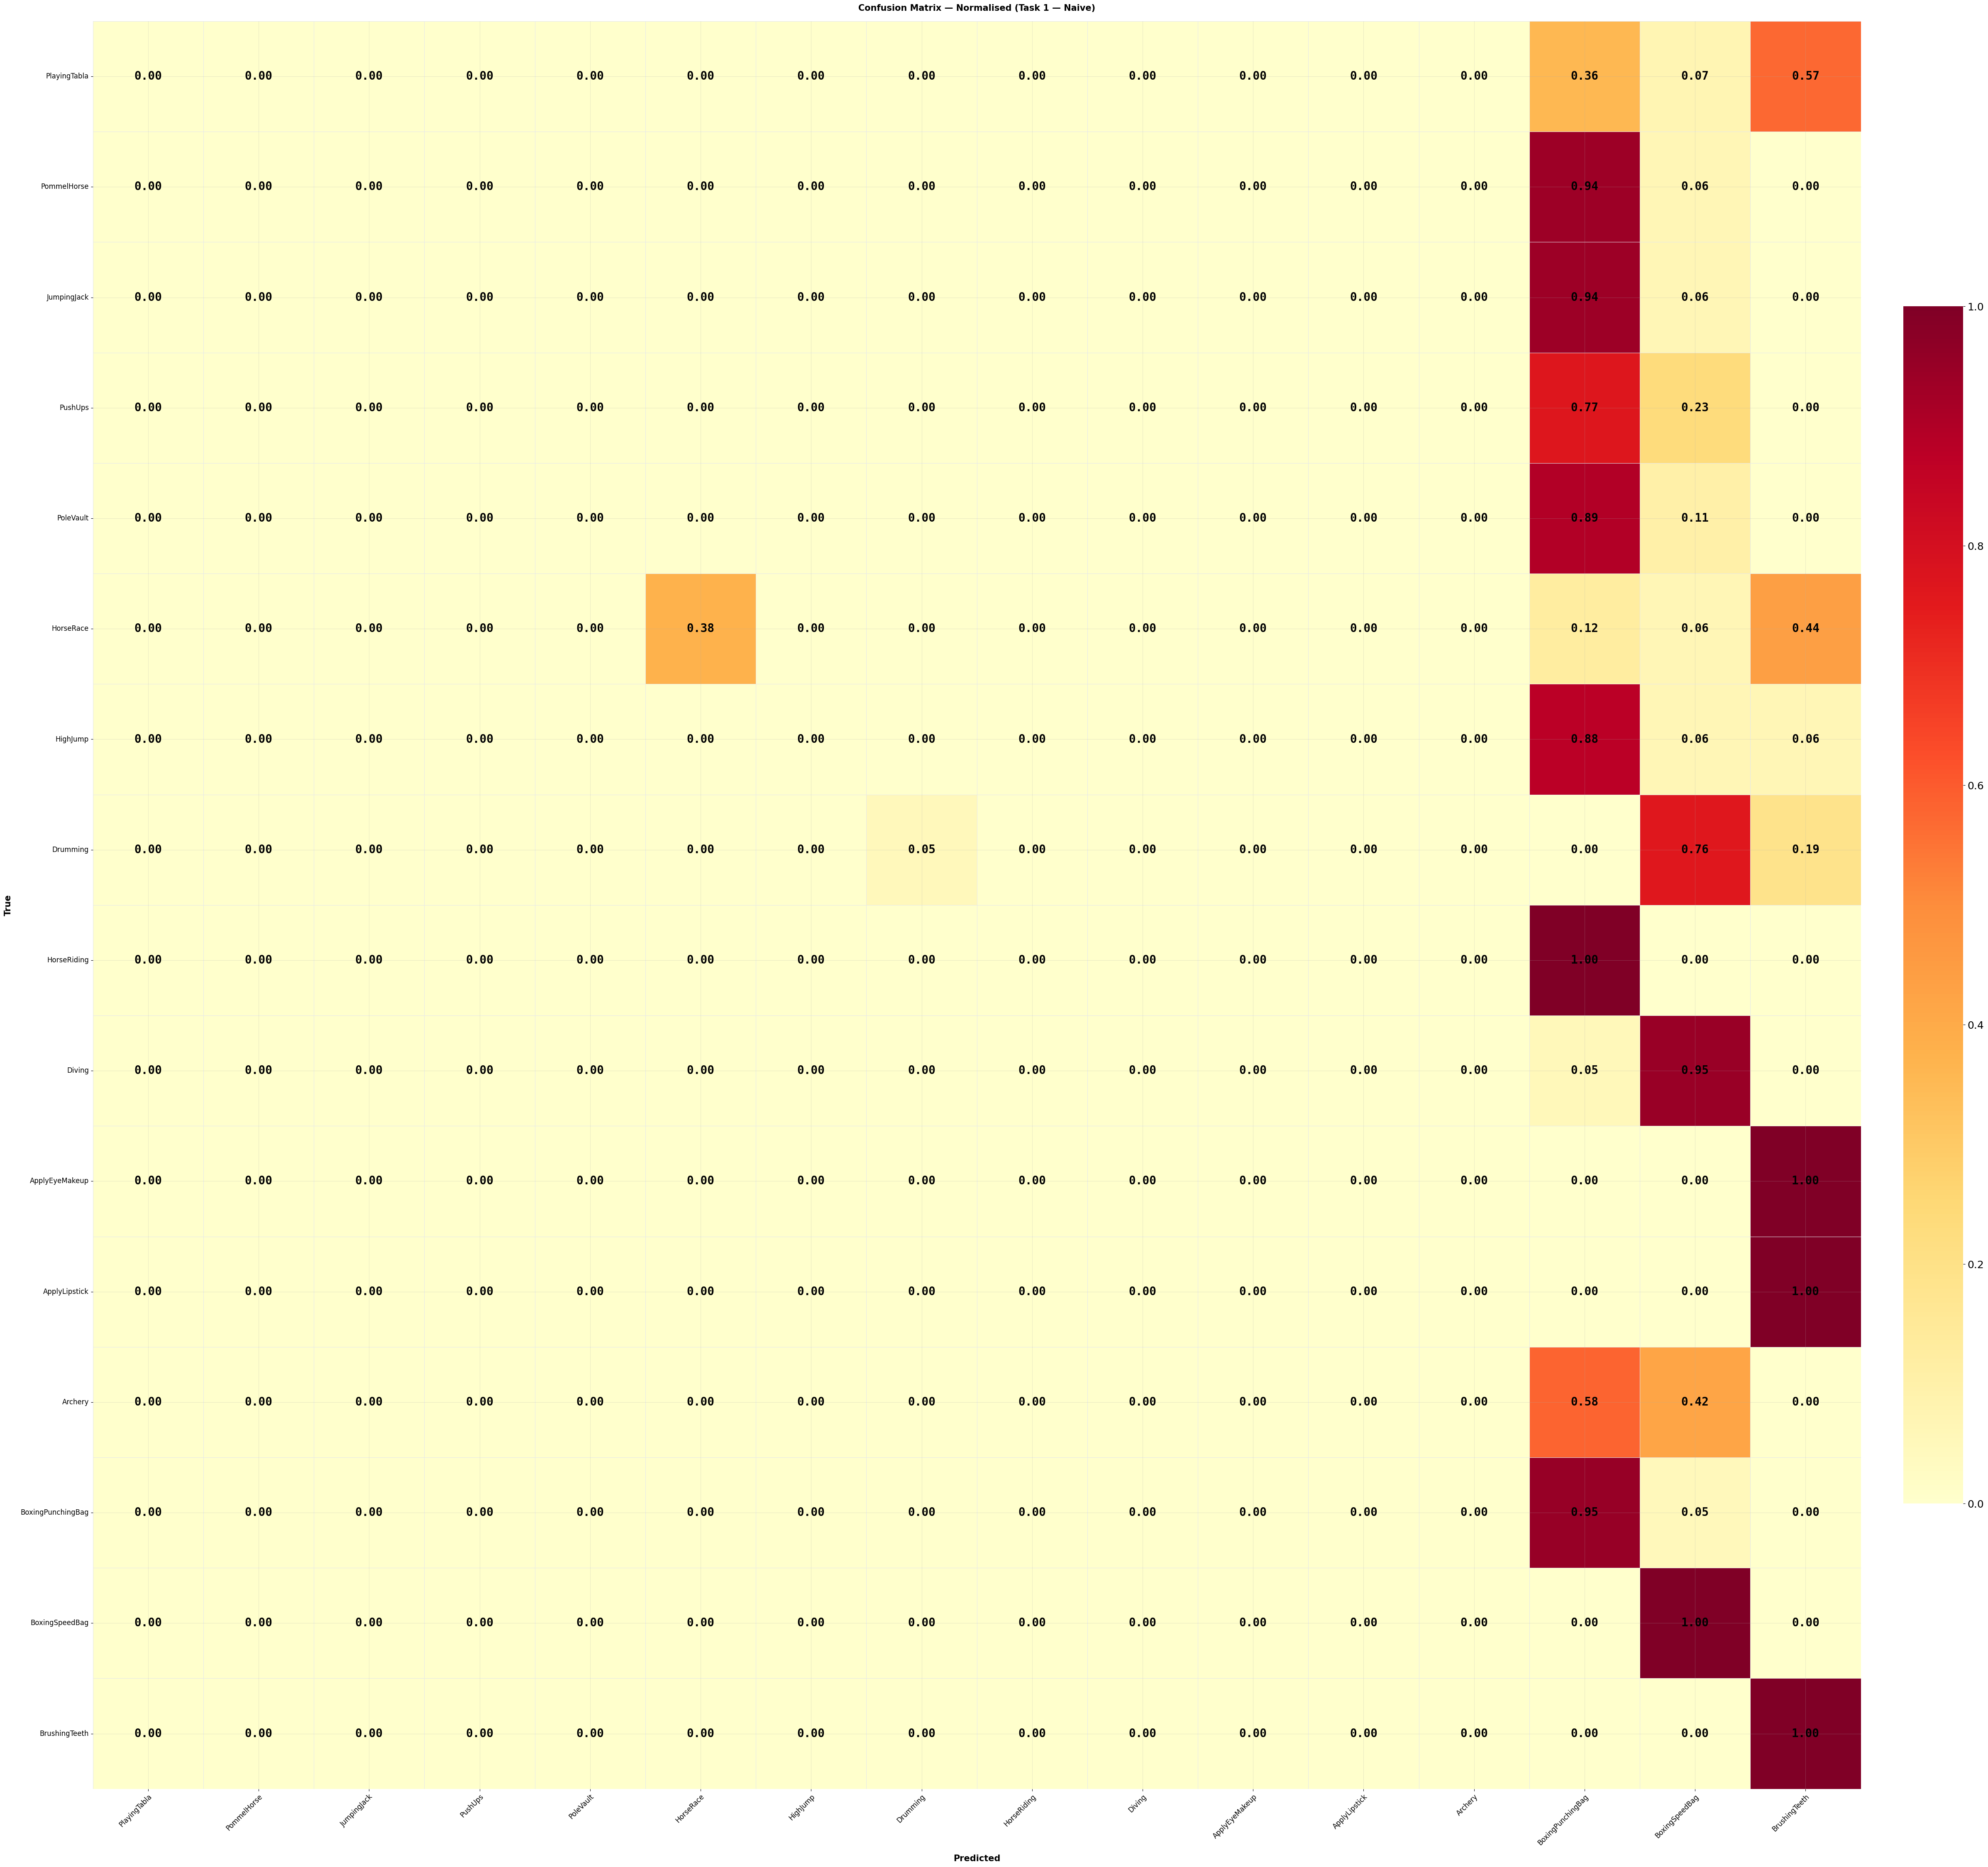

In [28]:
_, all_preds, all_labels = test_model(model_task2, combined_test_loader2, device)

plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    name         = "Task 1 — Naive",
)

In [29]:
print_detailed_metrics(
    all_labels   = all_labels,
    all_preds    = all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    split_old    = (0, len(cfg.SELECTED_CLASSES)),               # base: 0–9
    split_new    = (len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST)),  # task1: 10–14
)


METRICS FOR 16 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.2186
  Precision : 0.1735
  Recall    : 0.2186
  F1-Score  : 0.1053

PER-CLASS REPORT 
                   precision    recall  f1-score   support

     PlayingTabla       0.00      0.00      0.00        14
      PommelHorse       0.00      0.00      0.00        16
      JumpingJack       0.00      0.00      0.00        16
          PushUps       0.00      0.00      0.00        13
        PoleVault       0.00      0.00      0.00        19
        HorseRace       1.00      0.38      0.55        16
         HighJump       0.00      0.00      0.00        16
         Drumming       1.00      0.05      0.09        21
      HorseRiding       0.00      0.00      0.00        21
           Diving       0.00      0.00      0.00        19
   ApplyEyeMakeup       0.00      0.00      0.00        19
    ApplyLipstick       0.00      0.00      0.00        15
          Archery       0.00      0.00      0.00        19
BoxingPunchingBag  

## **Task 3**
- [TODO]